In [79]:
import pandas as pd
import qutip as qt
from qutip import *
from scipy.sparse.linalg import eigs
settings.core = CoreOptions(default_dtype='CSR')
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
from matplotlib import rc
import matplotlib as mpl
import scipy.optimize as opt
rc('text', usetex=True)
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = "STIX"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["legend.borderpad"] = 0.15
mpl.rcParams["font.size"] = 8
mpl.rcParams["lines.linewidth"] = 0.75
mpl.rcParams["xtick.major.size"] = 1.5
mpl.rcParams["ytick.major.size"] = 1.5
mpl.rcParams["xtick.minor.size"] = 1.0
mpl.rcParams["ytick.minor.size"] = 1.0
mpl.rcParams["xtick.major.pad"] = 1.5
mpl.rcParams["ytick.major.pad"] = .5
mpl.rcParams["xtick.minor.pad"] = 1.5
mpl.rcParams["ytick.minor.pad"] = .5

Helper functions for plotting.

In [80]:
def sqrt_QFI_approx(N):
    """Analytical approximation for the long time QFI rate computed in the main
    text."""
    return np.sqrt(8*(N*(N-1)*(N+2)*(N+3)/240*(2/9)) + 2/3*N*(N+2))
def QFI_approx(N):
    """Analytical approximation for the long time QFI rate computed in the main
    text."""
    return 8*(N*(N-1)*(N+2)*(N+3)/240*(2/9)) + 2/3*N*(N+2)
def fit_func(x, A, B):
    """"Power-law fit function."""
    return A*x**(-B) 

In [81]:
#------------------------------------------------------------------------------#
ratios=[4, 0.25] # omega/omega_c values to iterate over
Ns=[6] # system sizes to iterate over
#------------------------------------------------------------------------------#
QFI = np.array([np.zeros(3)]) #initialize array to store data, each row
                                #corresponds to [N, omega/omega_c, QFI]
#------------------------------------------------------------------------------#
for N in Ns: # iterate over system sizes
    print('Currently running N = ', N)
    # system parameterss
    ddphi = 5*10**(-5) # small increment for phase shift for numerical derivatives
    omega_c = N/2 # critical frequency for given system size N
    # Collective spin operators for the sensor
    S_x = qt.jmat(N/2, 'x')
    S_y = qt.jmat(N/2, 'y')
    S_z = qt.jmat(N/2, 'z')
    S_p = qt.jmat(N/2, '+')
    S_m = qt.jmat(N/2, '-')
    idenJ = qt.qeye(S_z.shape[0])
#------------------------------------------------------------------------------#
    def deformed_L(omega, ddphi):
        """Function that builds the vectorized Lindblad Superoperator for the
        deformed Master Equation."""
        H = omega*S_x
        HT = (H.dag()).conj()
        SpSmT = ((S_p*S_m).dag()).conj()
        Lphi = (-1j*(qt.tensor(idenJ, H)-qt.tensor(HT, idenJ))
        -0.5*qt.tensor(idenJ, S_p*S_m)-0.5*qt.tensor(SpSmT, idenJ)
        +np.exp(-1j*(ddphi))*qt.tensor(S_m.conj(), S_m))
        return Lphi
#------------------------------------------------------------------------------#
    def dominant_eigval(L):
        """Function that diagonalizes a Master operator and returns its
        dominant eigenvalue."""
        evals = L.eigenenergies(sparse=True, sort='high', eigvals=1)
        return np.real(evals[0])
#------------------------------------------------------------------------------#
    for ratio in ratios: # iterate over omega/omega_c values
        omega = ratio*omega_c
        # Δφ + δφ, ω=beta*omega_c
        lambda_EP = dominant_eigval(deformed_L(omega,ddphi))
        # Δφ - δφ, ω=beta*omega_c
        lambda_EM = dominant_eigval(deformed_L(omega,-ddphi))
        QFI = np.append(QFI,[[N, ratio,-4*(lambda_EP+lambda_EM)/(ddphi*ddphi)]], 
                        axis=0)
#------------------------------------------------------------------------------#

Currently running N =  6


Plot Fig. 4

Power-law fit parameters for $\Delta\varphi=0.005$: $\alpha,b=$ [1.98659829 1.22163851] $\Delta\alpha, \Delta b = $ [0.0704511  0.01794109]
Power-law fit parameters for $\Delta\varphi=0.01$: $\alpha,b=$ [1.46273932 1.03852383] $\Delta\alpha,\Delta b= [0.09007054 0.03020068]


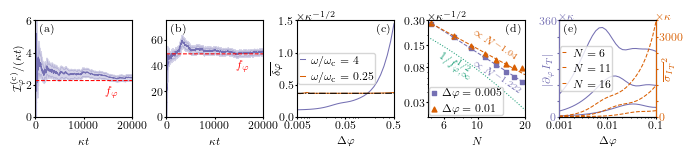

In [109]:
fig, axs = plt.subplots(1, 5, figsize=(510/72.27, 1.55),
                        width_ratios=[1, 1, 1, 1, 1])
plt.subplots_adjust(left=0.085, right=0.965, bottom=0.24, top=0.86, wspace=0.35)

colors=['#1b9e77','#d95f02','#7570b3']
marker = ['o', 's', '^']

#------------------------------------------------------------------------------#
# Load time-resolved FI data

df1 = pd.read_csv("FI_time_resolved_N6_ratio0.25.dat", sep=r'\s+', header=None)
df1.columns = ["t", "FI", "std"]
df1 = df1[df1["t"] >= 0]
df2 = pd.read_csv("FI_time_resolved_N6_ratio4.dat", sep=r'\s+', header=None)
df2.columns = ["t", "FI", "std"]
df2 = df2[df2["t"] >= 0]

#------------------------------------------------------------------------------#
# Fig. 4(a)

axs[0].plot(df1["t"], df1["FI"]/df1["t"], color=colors[2])
axs[0].fill_between(df1["t"], (df1["FI"]-df1["std"])/df1["t"],
                    (df1["FI"]+df1["std"])/df1["t"], alpha=0.3, color=colors[2])
axs[0].plot(df1["t"], QFI[2][2]*np.ones(len(df1["t"])),
            color='r', linestyle='dashed')
axs[0].text(1.45e4, QFI[2][2] - 0.4, r'$f_\varphi$', fontsize=8,
            color='r', verticalalignment='top')
axs[0].set_xlabel(r"$\kappa t$")
axs[0].set_ylabel(r"$\mathcal{I}^{(\mathrm{c})}_\varphi /(\kappa t)$")
axs[0].set_ylim([0, 6])
axs[0].set_xlim([-100, 2e4])
axs[0].set_xticks([0, 10000, 20000])
axs[0].set_xticklabels([0, r'$10000$', r'$20000$'])
axs[0].yaxis.set_label_coords(-0.1, 0.5)
axs[0].text(0.05, 0.97, '(a)', transform=axs[0].transAxes,
            horizontalalignment='left', verticalalignment='top')

#------------------------------------------------------------------------------#
# Fig. 4(b)

axs[1].plot(df2["t"], df2["FI"]/df2["t"], color=colors[2])
axs[1].fill_between(df2["t"], (df2["FI"]-df2["std"])/df2["t"],
                    (df2["FI"]+df2["std"])/df2["t"], alpha=0.3, color=colors[2])
axs[1].plot(df2["t"], QFI[1][2]*np.ones(len(df2["t"])),
            color='r', linestyle='dashed')
axs[1].text(1.45e4, QFI[1][2] - 5, r'$f_\varphi$', fontsize=8,
            color='r', verticalalignment='top')
axs[1].set_xlabel(r"$\kappa t$")
axs[1].set_xlim([-100, 2e4])
axs[1].set_ylim([0, 75])
axs[1].set_xticks([0, 10000, 20000])
axs[1].set_xticklabels([0, r'$10000$', r'$20000$'])
axs[1].text(0.05, 0.97, '(b)', transform=axs[1].transAxes,
            horizontalalignment='left', verticalalignment='top')

#------------------------------------------------------------------------------#
# Fig. 4(c)

df  = pd.read_csv('est_err_abs_fig4a_N11.csv')
df  = pd.DataFrame(df)

axs[2].plot(df['phi'].loc[(df['ratio']==4)],
            df['err'].loc[(df['ratio']==4)],
            color=colors[2], label=r'$\omega/\omega_\mathrm{c}=4$')
axs[2].plot(df['phi'].loc[(df['ratio']==0.25)],
            df['err'].loc[(df['ratio']==0.25)],
            color=colors[1], label=r'$\omega/\omega_\mathrm{c}=0.25$')
omega = 11/2*0.25
axs[2].plot(5*np.logspace(-3,-1,10,True,10),
            np.sqrt((1-np.cos(np.logspace(-3,-1,10,True,10)))
                    /(2*omega**2*np.sin(np.logspace(-3,-1,10,True,10))**2)),
            'k-.')
axs[2].set_yscale('linear')
axs[2].legend(fontsize=8, handletextpad=0.5, loc='center left', handlelength=0.5, borderaxespad=0.1)
axs[2].set_ylabel(r'$\overline{\delta\varphi}$')
axs[2].set_xlabel(r'$\Delta\varphi$')
axs[2].set_xlim(0.005, 0.5)
axs[2].set_xscale('log')
axs[2].set_xticks([0.005, 0.05, 0.5])
axs[2].set_xticklabels(['0.005', '0.05', '0.5'])
axs[2].set_ylim(0.0, 1.5)
axs[2].set_yticks([0.0, 0.5, 1, 1.5])
axs[2].yaxis.set_label_coords(-0.14, 0.5)
axs[2].text(0.97, 0.97, '(c)', transform=axs[2].transAxes,
            horizontalalignment='right', verticalalignment='top')
axs[2].text(0, 1, r'$\times \kappa^{-1/2}$', transform=axs[2].transAxes,
            horizontalalignment='left', verticalalignment='bottom')

#------------------------------------------------------------------------------#
# Fig. 4(d)

df = pd.read_csv('est_err_abs_fig4b.csv')
df = pd.DataFrame(df)

popt1, pcov1 = opt.curve_fit(fit_func, df['N'].loc[(df['phi']==0.005)],
                              df['err'].loc[(df['phi']==0.005)])
popt2, pcov2 = opt.curve_fit(fit_func, df['N'].loc[(df['phi']==0.01)],
                              df['err'].loc[(df['phi']==0.01)])
print(r'Power-law fit parameters for $\Delta\varphi=0.005$: $\alpha,b=$', popt1,
      r'$\Delta\alpha, \Delta b = $', np.sqrt(np.diag(pcov1)))
print(r'Power-law fit parameters for $\Delta\varphi=0.01$: $\alpha,b=$', popt2,
      r'$\Delta\alpha,\Delta b=', np.sqrt(np.diag(pcov2)))

axs[3].scatter(df['N'].loc[df['phi']==0.005], df['err'].loc[df['phi']==0.005],
               marker=marker[1], color=colors[2], label=r'$\Delta\varphi=0.005$', s=12)
axs[3].scatter(df['N'].loc[df['phi']==0.01], df['err'].loc[df['phi']==0.01],
               marker=marker[2], color=colors[1], label=r'$\Delta\varphi=0.01$', s=12)
axs[3].plot(np.linspace(5, 20, 10), fit_func(np.linspace(5, 20, 10), *popt1),
            color=colors[2], linestyle='dashed')
axs[3].plot(np.linspace(5, 20, 10), fit_func(np.linspace(5, 20, 10), *popt2),
            color=colors[1], linestyle='dashed')
axs[3].plot(np.linspace(4.75, 20, 100), 1/sqrt_QFI_approx(np.linspace(4.75, 20, 100)),
            color=colors[0], linestyle='dotted')
axs[3].set_yscale('log')
axs[3].set_xscale('log')
axs[3].set_yticks([0.3, 0.15, 0.08, 0.03])
axs[3].set_yticklabels(['0.30', '0.15', '0.08', '0.03'])
axs[3].set_xticks([6, 10, 20])
axs[3].set_xticklabels(['6', '10', '20'])
axs[3].set_xlabel(r'$N$')
axs[3].set_xlim(4.75, 20)
axs[3].set_ylim(0.02, 0.3)
axs[3].legend(loc='lower left', handletextpad=0.5, handlelength=0.5, borderaxespad=0.1)
axs[3].text(0.09, 0.4, r'$1/f_{\varphi,\infty}^{1/2}$', color=colors[0],
            transform=axs[3].transAxes, rotation=-35)
axs[3].text(0.45, 0.225, r'$\propto N^{-1.222}$', color=colors[2],
            transform=axs[3].transAxes, rotation=-35)
axs[3].text(0.45, 0.58, r'$\propto N^{-1.04}$', color=colors[1],
            transform=axs[3].transAxes, rotation=-35)
axs[3].text(0.97, 0.97, '(d)', transform=axs[3].transAxes,
            horizontalalignment='right', verticalalignment='top')
axs[3].text(0, 1, r'$\times \kappa^{-1/2}$', transform=axs[3].transAxes,
            horizontalalignment='left', verticalalignment='bottom')

#------------------------------------------------------------------------------#
# Fig. 4(e)

ax_twin = axs[4].twinx()
df  = pd.read_csv('est_err_abs_fig4c.csv')
df  = pd.DataFrame(df)
df  = df.loc[df['N']==6]

axs[4].plot(df['phi'].loc[(df['ratio']==4)],
            df['abs_deriv'].loc[(df['ratio']==4)],
            color=colors[2], label=r'$N=6$')
ax_twin.plot(df['phi'].loc[(df['ratio']==4)],
             df['var'].loc[(df['ratio']==4)],
             color=colors[1], linestyle='--', label=r'$N=6$')

df  = pd.read_csv('est_err_abs_fig4c.csv')
df  = pd.DataFrame(df)
df  = df.loc[df['N']==11]

axs[4].plot(df['phi'].loc[(df['ratio']==4)],
            df['abs_deriv'].loc[(df['ratio']==4)],
            color=colors[2], label=r'$N=11$')
ax_twin.plot(df['phi'].loc[(df['ratio']==4)],
             df['var'].loc[(df['ratio']==4)],
             color=colors[1], linestyle='--', label=r'$N=11$')

df  = pd.read_csv('est_err_abs_fig4c.csv')
df  = pd.DataFrame(df)
df  = df.loc[df['N']==16]

axs[4].plot(df['phi'].loc[(df['ratio']==4)],
            df['abs_deriv'].loc[(df['ratio']==4)],
            color=colors[2], label=r'$N=16$')
ax_twin.plot(df['phi'].loc[(df['ratio']==4)],
             df['var'].loc[(df['ratio']==4)],
             color=colors[1], linestyle='--', label=r'$N=16$')

axs[4].set_ylabel(r'$|\partial_{\varphi}I_T |$', color=colors[2])
ax_twin.set_ylabel(r'$\overline{\sigma_{I_T}}^2$', color=colors[1])
axs[4].set_xscale('log')
axs[4].set_xticks([1e-3, 1e-2, 1e-1])
axs[4].set_xlim([1e-3, 1e-1])
axs[4].set_xticklabels([1e-3, 1e-2, 1e-1])
axs[4].set_ylim([0,3.6e2])
axs[4].set_yticks([0,60,120,180,240,300,360])
axs[4].set_yticklabels([0,'','','','','',360])
ax_twin.set_ylim([0,3600])
ax_twin.set_yticks([0,600,1200,1800,2400,3000,3600])
ax_twin.set_yticklabels([0,'','','','',3000,''])

ax_twin.spines['left'].set_color(colors[2])
axs[4].tick_params(axis='y', colors=colors[2], which='both')
ax_twin.spines['right'].set_color(colors[1])
ax_twin.tick_params(axis='y', colors=colors[1], which='both')

axs[4].set_xlabel(r'$\Delta\varphi$')
axs[4].yaxis.set_label_coords(-0.05, 0.5)
ax_twin.yaxis.set_label_coords(1.05, 0.5)
axs[4].text(0.05, 0.97, '(e)', transform=axs[4].transAxes,
            horizontalalignment='left', verticalalignment='top')
axs[4].text(0, 1, r'$\times \kappa$', color=colors[2],
            transform=axs[4].transAxes, horizontalalignment='left',
            verticalalignment='bottom')
ax_twin.text(1, 1, r'$\times \kappa$', color=colors[1],
             transform=ax_twin.transAxes, horizontalalignment='left',
             verticalalignment='bottom')
ax_twin.legend(loc='center left', fontsize=8, handletextpad=0.5, handlelength=0.5, borderaxespad=0.1)

fig.savefig('est_err_abs.pdf', dpi=1000)